# Projeto: Previsão de Atraso e Cancelamento de Voos

## Sumário
Este notebook atende às **Milestones 1 e 2**, mantendo a leitura dos dados **diretamente do Kaggle**.  
O objetivo desta versão é garantir uma preparação **coerente, limpa e pronta para a fase de modelação**.

## 1. Importação de Bibliotecas e Configuração do Ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from IPython.display import display

SEMENTE = 42
np.random.seed(SEMENTE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")

## 2. Carregamento do Conjunto de Dados

In [2]:
# caminho do ficheiro no Kaggle
caminho_dados = "/kaggle/input/datasets/nalisha/flight-delay-and-cancellation-data-1-million-2024/flight_data_2024.csv"

# carregamento do conjunto de dados
dados_brutos = pd.read_csv(caminho_dados)

print("Dimensão original do conjunto de dados:", dados_brutos.shape)
display(dados_brutos.head())

Dimensão original do conjunto de dados: (1048575, 18)


,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,"1,247.000",31.000,"1,318.000","1,442.000",7.000,0,84.000,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,"1,001.000",20.000,"1,021.000","1,249.000",6.000,0,88.000,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,"1,411.000",21.000,"1,432.000","1,533.000",8.000,0,61.000,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,"1,643.000",13.000,"1,656.000","1,747.000",12.000,0,51.000,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,"1,010.000",21.000,"1,031.000","1,016.000",4.000,0,45.000,237,0,0


## 3. Funções Auxiliares

Estas funções reduzem repetição, tornam o notebook mais legível e ajudam a manter o processo de preparação dos dados mais organizado.

In [3]:
def resumo_valores_em_falta(tabela: pd.DataFrame) -> pd.DataFrame:
    """Devolve uma tabela com a contagem e percentagem de valores em falta."""
    resumo = pd.DataFrame({
        "valores_em_falta": tabela.isna().sum(),
        "percentagem_em_falta": tabela.isna().mean() * 100
    }).sort_values("percentagem_em_falta", ascending=False)
    return resumo[resumo["valores_em_falta"] > 0]


def representar_taxa_alvo_por_grupo(
    tabela: pd.DataFrame,
    coluna_grupo: str,
    coluna_alvo: str = "cancelled",
    titulo: str | None = None,
    rotacao_x: int = 0,
    top_n: int | None = None
) -> pd.DataFrame:
    """Calcula e representa a taxa média da variável-alvo por grupo."""
    taxa_por_grupo = (
        tabela.groupby(coluna_grupo)[coluna_alvo]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    if top_n is not None:
        taxa_por_grupo = taxa_por_grupo.head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=taxa_por_grupo, x=coluna_grupo, y=coluna_alvo)
    plt.title(titulo if titulo else f"Taxa média de {coluna_alvo} por {coluna_grupo}")
    plt.xlabel(coluna_grupo)
    plt.ylabel(f"Taxa média de {coluna_alvo}")
    plt.xticks(rotation=rotacao_x)
    plt.tight_layout()
    plt.show()

    return taxa_por_grupo


def obter_periodo_do_dia(hora_partida: float) -> str:
    """Classifica a hora prevista de partida em períodos do dia com base no formato HHMM."""
    if pd.isna(hora_partida):
        return "desconhecido"
    if 0 <= hora_partida < 600:
        return "madrugada"
    if 600 <= hora_partida < 1200:
        return "manha"
    if 1200 <= hora_partida < 1800:
        return "tarde"
    return "noite"


def construir_conjunto_pre_partida(tabela: pd.DataFrame) -> pd.DataFrame:
    """Constrói um conjunto de modelação sem variáveis com fuga de informação temporal."""
    colunas_selecionadas = [
        "month",
        "day_of_month",
        "day_of_week",
        "origin",
        "distance",
        "is_long_flight",
        "cancelled",
    ]
    return tabela[colunas_selecionadas].copy()

## 4. Inspeção Inicial dos Dados

Esta secção corresponde ao conhecimento inicial dos dados e cria a base para a exploração e limpeza seguintes.

In [4]:
dados = dados_brutos.copy()

print("Dimensão do conjunto de dados:", dados.shape)
print("\nTipos de dados:")
print(dados.dtypes)

print("\nInformação geral do DataFrame:")
dados.info()

Dimensão do conjunto de dados: (1048575, 18)

Tipos de dados:
year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
origin                  object
origin_city_name        object
origin_state_nm         object
dep_time               float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
cancelled                int64
air_time               float64
distance                 int64
weather_delay            int64
late_aircraft_delay      int64
dtype: object

Informação geral do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   year                 1048575 non-null  int64  
 1   month                1048575 non-null  int64  
 2   day_of_m

In [5]:
# estatísticas descritivas das variáveis numéricas
display(dados.describe().T)

,count,mean,std,min,25%,50%,75%,max
year,"1,048,575.000","2,024.000",0.000,"2,024.000","2,024.000","2,024.000","2,024.000","2,024.000"
month,"1,048,575.000",1.478,0.500,1.000,1.000,1.000,2.000,2.000
day_of_month,"1,048,575.000",15.305,8.586,1.000,8.000,15.000,23.000,31.000
day_of_week,"1,048,575.000",3.893,2.010,1.000,2.000,4.000,6.000,7.000
dep_time,"1,026,022.000","1,325.074",497.299,1.000,911.000,"1,323.000","1,736.000","2,400.000"
taxi_out,"1,025,450.000",18.250,10.440,1.000,12.000,15.000,21.000,213.000
wheels_off,"1,025,450.000","1,349.996",498.043,1.000,929.000,"1,337.000","1,750.000","2,400.000"
wheels_on,"1,024,898.000","1,476.156",519.868,1.000,"1,058.000","1,510.000","1,914.000","2,400.000"
taxi_in,"1,024,898.000",8.083,6.513,1.000,4.000,6.000,9.000,444.000
cancelled,"1,048,575.000",0.022,0.147,0.000,0.000,0.000,0.000,1.000


In [6]:
# separação entre variáveis numéricas e categóricas
colunas_numericas = dados.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = dados.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas:", colunas_numericas)
print("\nVariáveis categóricas:", colunas_categoricas)

Variáveis numéricas: ['year', 'month', 'day_of_month', 'day_of_week', 'dep_time', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'cancelled', 'air_time', 'distance', 'weather_delay', 'late_aircraft_delay']

Variáveis categóricas: ['fl_date', 'origin', 'origin_city_name', 'origin_state_nm']


## 5. Verificação de Integridade

Nesta etapa são avaliados valores em falta, duplicados e a coerência do conjunto de dados.

In [7]:
# valores em falta
resumo_nulos = resumo_valores_em_falta(dados)
display(
    resumo_nulos
    if not resumo_nulos.empty
    else pd.DataFrame({"mensagem": ["Não existem valores em falta."]})
)

,valores_em_falta,percentagem_em_falta
air_time,25751,2.456
wheels_on,23677,2.258
taxi_in,23677,2.258
taxi_out,23125,2.205
wheels_off,23125,2.205
dep_time,22553,2.151


In [8]:
# registos duplicados
numero_duplicados = dados.duplicated().sum()
print(f"Número de registos duplicados: {numero_duplicados}")

Número de registos duplicados: 7401


### Comentário inicial sobre a qualidade dos dados

Observa-se a existência de valores em falta sobretudo em colunas operacionais relacionadas com a execução do voo, como `air_time`, `wheels_on` e `taxi_in`.  
Este comportamento é coerente com a existência de voos cancelados, nos quais provavelmente o voo nunca chegou a acontecer.

## 6. Preparação Temporal

In [9]:
# conversão da data para formato temporal
dados["fl_date"] = pd.to_datetime(dados["fl_date"], errors="coerce")

# conversão das principais variáveis categóricas
for coluna in ["origin", "origin_city_name", "origin_state_nm"]:
    dados[coluna] = dados[coluna].astype("category")

print("Data convertida e variáveis categóricas ajustadas com sucesso.")
print(dados.dtypes)

Data convertida e variáveis categóricas ajustadas com sucesso.
year                            int64
month                           int64
day_of_month                    int64
day_of_week                     int64
fl_date                datetime64[ns]
origin                       category
origin_city_name             category
origin_state_nm              category
dep_time                      float64
taxi_out                      float64
wheels_off                    float64
wheels_on                     float64
taxi_in                       float64
cancelled                       int64
air_time                      float64
distance                        int64
weather_delay                   int64
late_aircraft_delay             int64
dtype: object


## 7. Análise da Variável-Alvo

A variável-alvo desta versão do notebook é `cancelled`.  
O primeiro passo é avaliar o seu equilíbrio, dado que isso influencia a interpretação e a modelação futura.

,contagem,percentagem
cancelled,,
0,1025269,97.780
1,23306,2.220


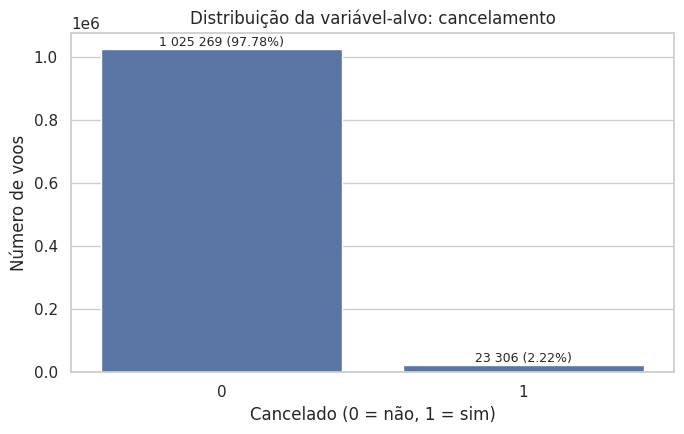

In [10]:
contagem_alvo = dados["cancelled"].value_counts().sort_index()
percentagem_alvo = dados["cancelled"].value_counts(normalize=True).sort_index() * 100

# Tabela resumo
tabela_alvo = pd.DataFrame({
    "contagem": contagem_alvo,
    "percentagem": percentagem_alvo.round(2)
})

display(tabela_alvo)

# Gráfico principal
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=dados, x="cancelled")

plt.title("Distribuição da variável-alvo: cancelamento")
plt.xlabel("Cancelado (0 = não, 1 = sim)")
plt.ylabel("Número de voos")

# Adicionar rótulos com contagem e percentagem
total_voos = len(dados)

for barra in ax.patches:
    altura = barra.get_height()
    percentagem = (altura / total_voos) * 100
    ax.annotate(
        f"{int(altura):,} ({percentagem:.2f}%)".replace(",", " "),
        (barra.get_x() + barra.get_width() / 2, altura),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Conclusão Visual**  
A variável-alvo está **fortemente desequilibrada**, com clara predominância de voos não cancelados.  
Este aspeto deverá ser tido em conta na fase de modelação, nomeadamente na escolha de métricas e técnicas de validação.

## 8. Análise Exploratória

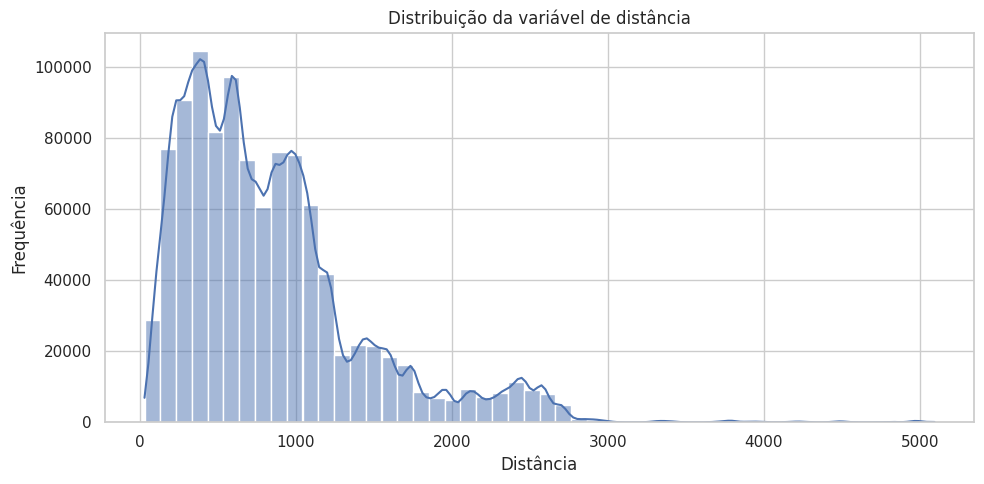

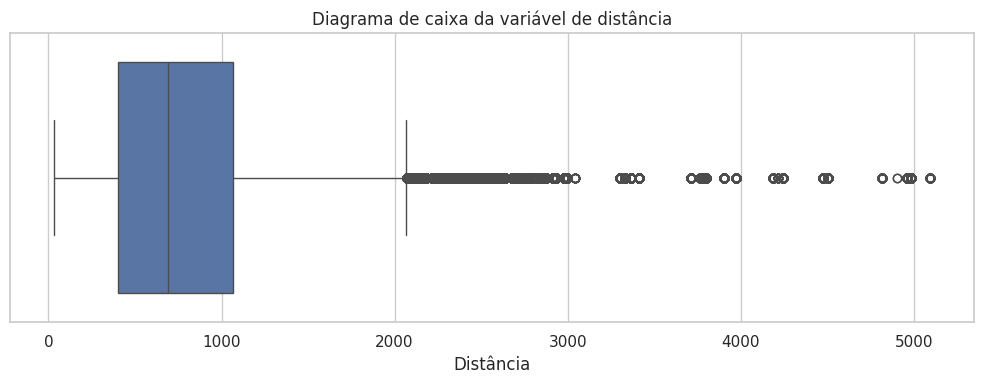

In [11]:
# distribuição da distância do voo
plt.figure(figsize=(10, 5))
sns.histplot(dados["distance"], bins=50, kde=True)
plt.title("Distribuição da variável de distância")
plt.xlabel("Distância")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=dados["distance"])
plt.title("Diagrama de caixa da variável de distância")
plt.xlabel("Distância")
plt.tight_layout()
plt.show()

Meses presentes no dataset: [np.int64(1), np.int64(2)]
Número de meses distintos: 2


,mês,taxa_cancelamento (%)
0,1,3.726
1,2,0.582


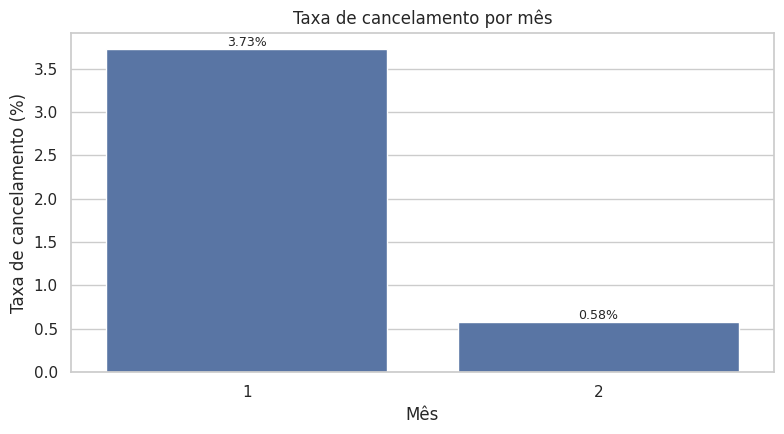

In [12]:
# Verificação prévia dos meses disponíveis
print("Meses presentes no dataset:", sorted(dados["month"].dropna().unique()))
print("Número de meses distintos:", dados["month"].nunique())

# Cálculo da taxa média de cancelamento por mês
taxa_cancelamento_mes = (
    dados.groupby("month", as_index=False)["cancelled"]
    .mean()
    .rename(columns={
        "month": "mês",
        "cancelled": "taxa_cancelamento"
    })
    .sort_values("mês")
)

# Converter para percentagem para facilitar a leitura
taxa_cancelamento_mes["taxa_cancelamento_pct"] = taxa_cancelamento_mes["taxa_cancelamento"] * 100

display(taxa_cancelamento_mes[["mês", "taxa_cancelamento_pct"]].rename(columns={
    "taxa_cancelamento_pct": "taxa_cancelamento (%)"
}))

# Gráfico
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=taxa_cancelamento_mes,
    x="mês",
    y="taxa_cancelamento_pct"
)

plt.title("Taxa de cancelamento por mês")
plt.xlabel("Mês")
plt.ylabel("Taxa de cancelamento (%)")

# Rótulos nas barras
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(
        f"{altura:.2f}%",
        (barra.get_x() + barra.get_width() / 2, altura),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Conclusão Visual**  
Observa-se variação na taxa de cancelamento entre os meses presentes no conjunto de dados. Contudo, dado que a análise não inclui a totalidade dos meses do ano, não é possível retirar conclusões certas para já sobre a sazonalidade.

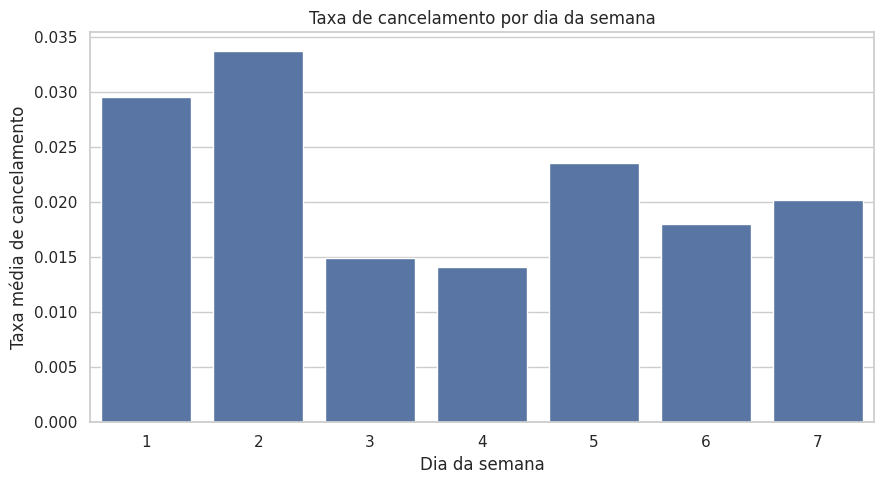

,day_of_week,cancelled
0,1,0.030
1,2,0.034
2,3,0.015
3,4,0.014
4,5,0.024
5,6,0.018
6,7,0.020


In [13]:
# taxa de cancelamento por dia da semana
taxa_cancelamento_dia_semana = (
    dados.groupby("day_of_week")["cancelled"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=taxa_cancelamento_dia_semana, x="day_of_week", y="cancelled")
plt.title("Taxa de cancelamento por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Taxa média de cancelamento")
plt.tight_layout()
plt.show()

display(taxa_cancelamento_dia_semana)

,aeroporto_origem,frequencia
0,ATL,50297
1,DFW,45521
2,DEN,44327
3,ORD,39179
4,CLT,31667
5,PHX,29683
6,LAX,28874
7,LAS,28492
8,MCO,27392
9,LGA,24990


<Figure size 640x480 with 0 Axes>

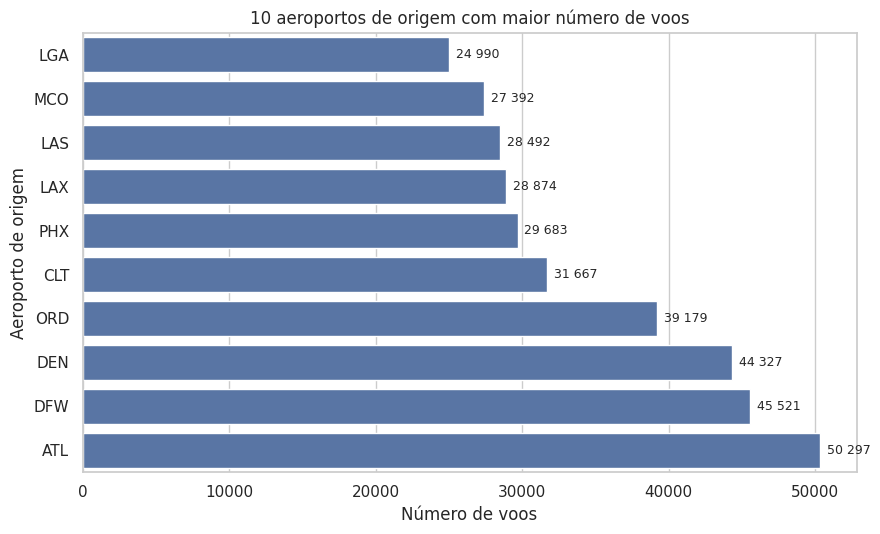

In [14]:
# Número de aeroportos a apresentar
top_n = 10

# Cálculo das frequências dos aeroportos de origem
frequencia_top_origens = (
    dados["origin"]
    .value_counts()
    .head(top_n)
    .rename_axis("aeroporto_origem")
    .reset_index(name="frequencia")
)

# Ordenar para o gráfico horizontal ficar mais legível
frequencia_top_origens = frequencia_top_origens.sort_values("frequencia", ascending=True)

# Garantir que só existem estas categorias
frequencia_top_origens["aeroporto_origem"] = pd.Categorical(
    frequencia_top_origens["aeroporto_origem"],
    categories=frequencia_top_origens["aeroporto_origem"],
    ordered=True
)

display(frequencia_top_origens.sort_values("frequencia", ascending=False))

# Limpar estado anterior (evita "lixo" no eixo)
plt.clf()

# Gráfico melhorado
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(
    data=frequencia_top_origens,
    x="frequencia",
    y="aeroporto_origem",
    order=frequencia_top_origens["aeroporto_origem"]
)

plt.title("10 aeroportos de origem com maior número de voos")
plt.xlabel("Número de voos")
plt.ylabel("Aeroporto de origem")

# Adicionar rótulos no fim de cada barra
for barra in ax.patches:
    largura = barra.get_width()
    ax.annotate(
        f"{int(largura):,}".replace(",", " "),
        (largura, barra.get_y() + barra.get_height() / 2),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

,aeroporto_origem,taxa_cancelamento (%)
9,ORD,3.762
8,LGA,3.365
7,DEN,2.696
6,LAX,1.853
5,LAS,1.699
...,...,...
329,WRG,NaN
330,XNA,NaN
331,XWA,NaN
332,YAK,NaN


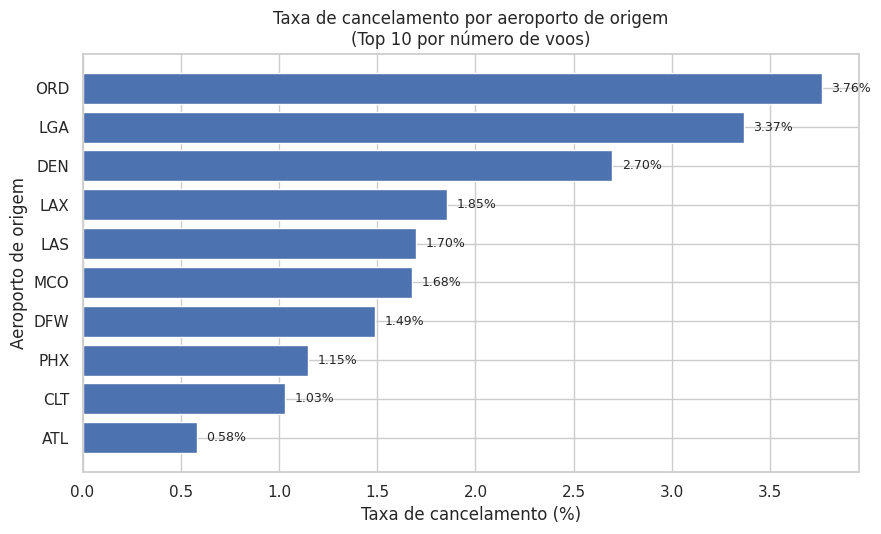

In [15]:
# Fechar figuras anteriores para evitar herdar eixos/categorias
plt.close("all")

# Selecionar os 10 aeroportos com mais voos
top_origens = dados["origin"].value_counts().head(10).index

# Calcular taxa de cancelamento apenas para esses aeroportos
taxa_cancelamento_origem = (
    dados[dados["origin"].isin(top_origens)]
    .groupby("origin", as_index=False)["cancelled"]
    .mean()
    .rename(columns={
        "origin": "aeroporto_origem",
        "cancelled": "taxa_cancelamento"
    })
)

# Converter para percentagem
taxa_cancelamento_origem["taxa_cancelamento_pct"] = (
    taxa_cancelamento_origem["taxa_cancelamento"] * 100
)

# Ordenar para o gráfico horizontal ficar mais legível
taxa_cancelamento_origem = taxa_cancelamento_origem.sort_values(
    "taxa_cancelamento_pct", ascending=True
).reset_index(drop=True)

# Mostrar tabela limpa
display(
    taxa_cancelamento_origem[["aeroporto_origem", "taxa_cancelamento_pct"]]
    .rename(columns={"taxa_cancelamento_pct": "taxa_cancelamento (%)"})
    .sort_values("taxa_cancelamento (%)", ascending=False)
)

# Criar figura e eixo novos
fig, ax = plt.subplots(figsize=(9, 5.5))

# Gráfico horizontal com matplotlib puro
ax.barh(
    taxa_cancelamento_origem["aeroporto_origem"],
    taxa_cancelamento_origem["taxa_cancelamento_pct"]
)

ax.set_title("Taxa de cancelamento por aeroporto de origem\n(Top 10 por número de voos)")
ax.set_xlabel("Taxa de cancelamento (%)")
ax.set_ylabel("Aeroporto de origem")

# Adicionar rótulos no fim de cada barra
for i, valor in enumerate(taxa_cancelamento_origem["taxa_cancelamento_pct"]):
    ax.text(
        valor + 0.05,
        i,
        f"{valor:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

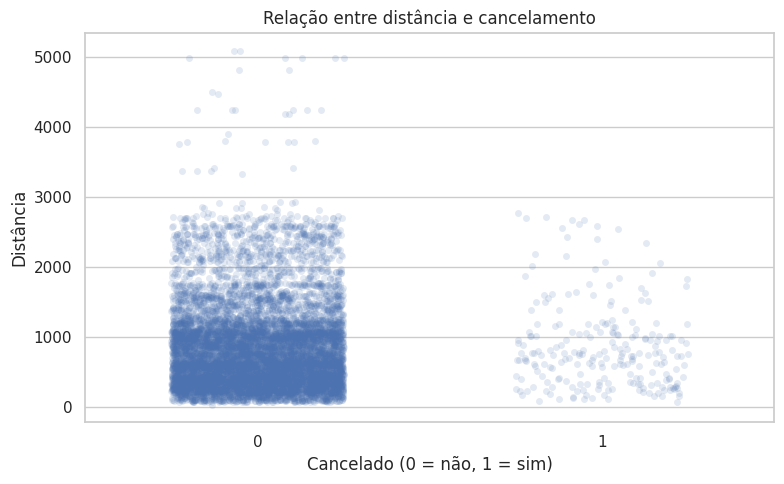

In [16]:
# relação entre distância e cancelamento com dispersão simplificada
amostra_grafico = dados.sample(min(10000, len(dados)), random_state=SEMENTE)

plt.figure(figsize=(8, 5))
sns.stripplot(
    data=amostra_grafico,
    x="cancelled",
    y="distance",
    jitter=0.25,
    alpha=0.15
)
plt.title("Relação entre distância e cancelamento")
plt.xlabel("Cancelado (0 = não, 1 = sim)")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()

**Conclusão Visual**  
A distância, por si só, não separa de forma clara os voos cancelados dos não cancelados, o que sugere que será necessário combinar esta variável com outra(s) para melhorar o desempenho dos modelos. 

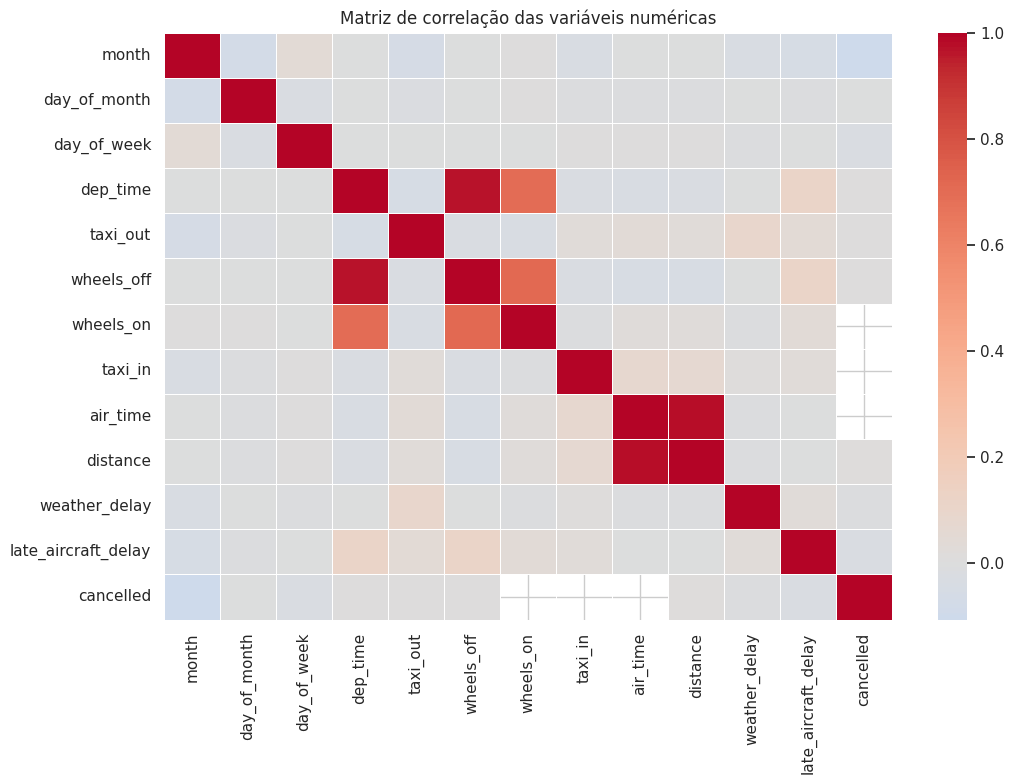

,correlacao_com_cancelamento
cancelled,1.000
distance,0.011
dep_time,0.009
taxi_out,0.007
wheels_off,0.006
day_of_month,-0.004
weather_delay,-0.009
day_of_week,-0.025
late_aircraft_delay,-0.027
month,-0.107


In [17]:
# mapa de correlação para variáveis numéricas
colunas_correlacao = [
    "month",
    "day_of_month",
    "day_of_week",
    "dep_time",
    "taxi_out",
    "wheels_off",
    "wheels_on",
    "taxi_in",
    "air_time",
    "distance",
    "weather_delay",
    "late_aircraft_delay",
    "cancelled"
]

matriz_correlacao = dados[colunas_correlacao].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(matriz_correlacao, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

display(
    matriz_correlacao["cancelled"]
    .sort_values(ascending=False)
    .to_frame("correlacao_com_cancelamento")
)

### Leitura do Mapa de Correlação

As variáveis operacionais associadas à execução de um voo apresentam relações mais próximas com `cancelled`, mas várias delas não são adequadas para modelação preditiva antecipada, por poderem introduzir fuga de informação (data leakage).

In [18]:
# relação entre valores em falta e cancelamento
nulos_por_alvo = pd.DataFrame({
    "falta_air_time": dados["air_time"].isna(),
    "falta_wheels_on": dados["wheels_on"].isna(),
    "falta_taxi_in": dados["taxi_in"].isna(),
    "cancelled": dados["cancelled"]
})

for coluna in ["falta_air_time", "falta_wheels_on", "falta_taxi_in"]:
    print(f"\nDistribuição de cancelamento segundo {coluna}:")
    display(pd.crosstab(nulos_por_alvo[coluna], nulos_por_alvo["cancelled"], normalize="index") * 100)


Distribuição de cancelamento segundo falta_air_time:


cancelled,0,1
falta_air_time,,
False,100.000,0.000
True,9.495,90.505



Distribuição de cancelamento segundo falta_wheels_on:


cancelled,0,1
falta_wheels_on,,
False,100.000,0.000
True,1.567,98.433



Distribuição de cancelamento segundo falta_taxi_in:


cancelled,0,1
falta_taxi_in,,
False,100.000,0.000
True,1.567,98.433


## 9. Limpeza dos Dados

In [19]:
# remoção de duplicados
linhas_antes = len(dados)
dados = dados.drop_duplicates().copy()
linhas_depois = len(dados)

print(f"Linhas antes da remoção de duplicados: {linhas_antes}")
print(f"Linhas depois da remoção de duplicados: {linhas_depois}")
print(f"Duplicados removidos: {linhas_antes - linhas_depois}")

Linhas antes da remoção de duplicados: 1048575
Linhas depois da remoção de duplicados: 1041174
Duplicados removidos: 7401


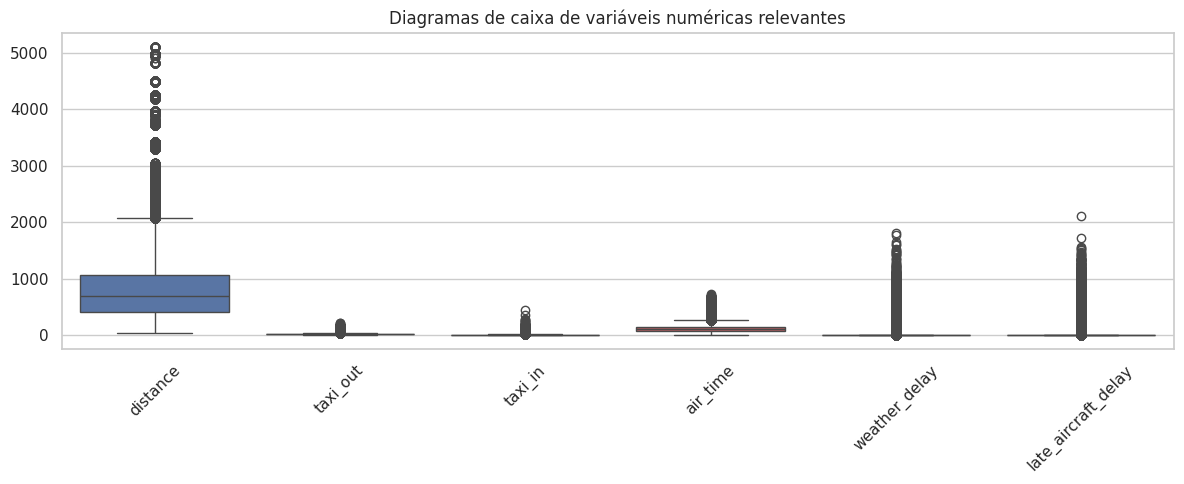

In [20]:
# identificação de valores extremos em variáveis numéricas relevantes
colunas_numericas_eda = [
    "distance",
    "taxi_out",
    "taxi_in",
    "air_time",
    "weather_delay",
    "late_aircraft_delay"
]

plt.figure(figsize=(12, 5))
sns.boxplot(data=dados[colunas_numericas_eda])
plt.title("Diagramas de caixa de variáveis numéricas relevantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# diagnóstico de valores extremos com base no intervalo interquartil
relatorio_outliers = []

for coluna in colunas_numericas_eda:
    serie = dados[coluna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    amplitude_iq = q3 - q1
    limite_inferior = q1 - 1.5 * amplitude_iq
    limite_superior = q3 + 1.5 * amplitude_iq
    numero_outliers = ((dados[coluna] < limite_inferior) | (dados[coluna] > limite_superior)).sum()
    relatorio_outliers.append({
        "variavel": coluna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "numero_outliers": int(numero_outliers)
    })

tabela_outliers = pd.DataFrame(relatorio_outliers).sort_values("numero_outliers", ascending=False)
display(tabela_outliers)

,variavel,limite_inferior,limite_superior,numero_outliers
5,late_aircraft_delay,0.000,0.000,99038
2,taxi_in,-3.500,16.500,70946
1,taxi_out,-1.500,34.500,61576
0,distance,-598.500,"2,069.500",61001
3,air_time,-60.500,271.500,48052
4,weather_delay,0.000,0.000,15895


In [22]:
# verificação de incoerências físicas com base na velocidade média aproximada do voo
dados["velocidade_media_kmh_tmp"] = np.where(
    dados["air_time"].notna() & (dados["air_time"] > 0),
    (dados["distance"] * 1.60934 / dados["air_time"]) * 60,
    np.nan
)

mascara_erro_fisico = (dados["velocidade_media_kmh_tmp"] > 1100) | (dados["velocidade_media_kmh_tmp"] < 160)

print(f"Total de potenciais erros físicos identificados: {mascara_erro_fisico.sum()}")
display(dados.loc[mascara_erro_fisico, ["origin", "distance", "air_time", "velocidade_media_kmh_tmp"]].head(20))

Total de potenciais erros físicos identificados: 23


,origin,distance,air_time,velocidade_media_kmh_tmp
27040,CLT,91,65.000,135.185
61615,MCO,1179,92.000,"1,237.443"
62500,DFW,89,70.000,122.770
79680,MCO,1179,98.000,"1,161.681"
100052,GSO,83,58.000,138.181
153705,CLT,75,60.000,120.700
299915,COS,73,47.000,149.977
394188,PSG,31,30.000,99.779
414734,DFW,158,108.000,141.264
415152,GSP,75,59.000,122.746


In [23]:
# remoção dos registos considerados fisicamente incoerentes
dados = dados.loc[~mascara_erro_fisico].copy()

# remoção da variável temporária criada apenas para diagnóstico
dados.drop(columns=["velocidade_media_kmh_tmp"], inplace=True)

print("Dimensão após remoção de erros físicos:", dados.shape)

Dimensão após remoção de erros físicos: (1041151, 18)


### Comentário sobre valores extremos e inconsistências

Os valores extremos foram inicialmente **identificados** para diagnóstico, mas não removidos de forma "bruta",  
pois no contexto aeronáutico vários valores extremos podem corresponder a situações reais.  
Já os registos com velocidade média fisicamente implausível foram removidos, por configurarem provável erro de registo.

## 10. Engenharia de Atributos

Nesta fase são criadas novas variáveis com potencial relevância para a modelação, e é analisada a sua relação com a variável-alvo.

In [24]:
# criação de novas variáveis
dados["is_long_flight"] = (dados["distance"] > 1500).astype(int)
dados["flight_period"] = dados["dep_time"].apply(obter_periodo_do_dia)

# o tempo total em solo apenas é calculado quando ambas as componentes existem
dados["ground_time"] = np.where(
    dados["taxi_out"].notna() & dados["taxi_in"].notna(),
    dados["taxi_out"] + dados["taxi_in"],
    np.nan
)

novas_variaveis = ["is_long_flight", "flight_period", "ground_time"]
print("Novas variáveis criadas:", novas_variaveis)
display(dados[novas_variaveis + ["cancelled"]].head())

Novas variáveis criadas: ['is_long_flight', 'flight_period', 'ground_time']


,is_long_flight,flight_period,ground_time,cancelled
0,0,tarde,38.000,0
1,0,manha,26.000,0
2,0,tarde,29.000,0
3,0,tarde,25.000,0
4,0,manha,25.000,0


In [25]:
# relação entre as novas variáveis e a variável-alvo
display(pd.crosstab(dados["is_long_flight"], dados["cancelled"], normalize="index") * 100)

display(pd.crosstab(dados["flight_period"], dados["cancelled"], normalize="index") * 100)

correlacao_tempo_solo = dados[["ground_time", "cancelled"]].corr().iloc[0, 1]
print(f"Correlação entre ground_time e cancelled: {correlacao_tempo_solo:.4f}")

cancelled,0,1
is_long_flight,,
0,98.575,1.425
1,97.749,2.251


cancelled,0,1
flight_period,,
desconhecido,0.000,100.000
madrugada,99.926,0.074
manha,99.944,0.056
noite,99.871,0.129
tarde,99.944,0.056


Correlação entre ground_time e cancelled: nan


,periodo_dia,taxa_cancelamento (%)
0,madrugada,0.074
1,tarde,0.056
2,noite,0.129
3,desconhecido,100.000
4,NaN,0.056


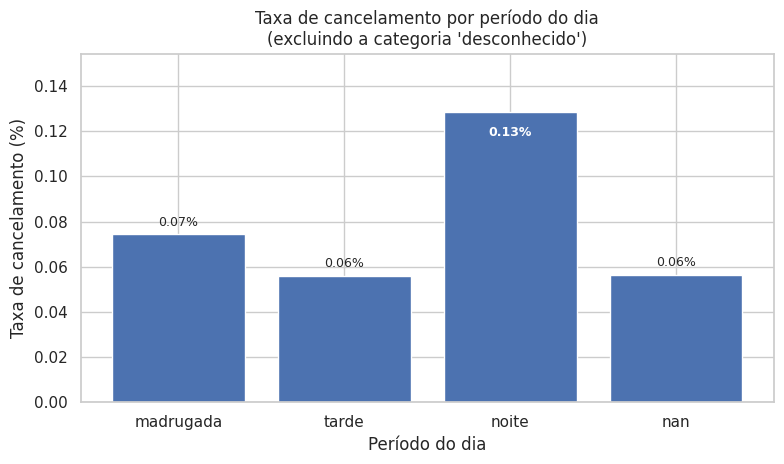

In [26]:
# Fechar figuras anteriores para evitar herdar estado visual
plt.close("all")

# Tabela completa, incluindo "desconhecido"
taxa_cancelamento_periodo = (
    dados.groupby("flight_period", as_index=False)["cancelled"]
    .mean()
    .rename(columns={
        "flight_period": "periodo_dia",
        "cancelled": "taxa_cancelamento"
    })
)

# Garantir ordem lógica dos períodos
ordem_periodos = ["madrugada", "manhã", "tarde", "noite", "desconhecido"]

taxa_cancelamento_periodo["periodo_dia"] = pd.Categorical(
    taxa_cancelamento_periodo["periodo_dia"],
    categories=ordem_periodos,
    ordered=True
)

taxa_cancelamento_periodo = taxa_cancelamento_periodo.sort_values("periodo_dia").reset_index(drop=True)

# Converter para percentagem
taxa_cancelamento_periodo["taxa_cancelamento_pct"] = (
    taxa_cancelamento_periodo["taxa_cancelamento"] * 100
)

# Mostrar tabela completa
display(
    taxa_cancelamento_periodo[["periodo_dia", "taxa_cancelamento_pct"]]
    .rename(columns={"taxa_cancelamento_pct": "taxa_cancelamento (%)"})
)

# Gráfico principal: excluir "desconhecido"
taxa_cancelamento_periodo_grafico = taxa_cancelamento_periodo[
    taxa_cancelamento_periodo["periodo_dia"] != "desconhecido"
].copy()

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    taxa_cancelamento_periodo_grafico["periodo_dia"].astype(str),
    taxa_cancelamento_periodo_grafico["taxa_cancelamento_pct"]
)

ax.set_title("Taxa de cancelamento por período do dia\n(excluindo a categoria 'desconhecido')")
ax.set_xlabel("Período do dia")
ax.set_ylabel("Taxa de cancelamento (%)")

# Ajustar limite do eixo Y (evita colisão com o título)
max_valor = taxa_cancelamento_periodo_grafico["taxa_cancelamento_pct"].max()
ax.set_ylim(0, max_valor * 1.2)

# labels inteligentes
for i, valor in enumerate(taxa_cancelamento_periodo_grafico["taxa_cancelamento_pct"]):

    if valor > max_valor * 0.8:
        # Dentro da barra (valores altos)
        ax.text(
            i,
            valor - (max_valor * 0.05),
            f"{valor:.2f}%",
            ha="center",
            va="top",
            fontsize=9,
            color="white",
            fontweight="bold"
        )
    else:
        # Acima da barra (valores normais)
        ax.text(
            i,
            valor + (max_valor * 0.02),
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 11. Considerações Finais para a Modelação

Nesta versão, são removidas variáveis redundantes e variáveis com risco claro de fuga de informação (data leakage).

In [27]:
# conjunto base para modelação sem fuga de informação
dados_modelacao = construir_conjunto_pre_partida(dados)

print("Dimensão inicial do conjunto de modelação:", dados_modelacao.shape)
display(dados_modelacao.head())

Dimensão inicial do conjunto de modelação: (1041151, 7)


,month,day_of_month,day_of_week,origin,distance,is_long_flight,cancelled
0,1,1,1,JFK,509,0,0
1,1,1,1,MSP,622,0,0
2,1,1,1,JFK,288,0,0
3,1,1,1,RIC,288,0,0
4,1,1,1,DTW,237,0,0


### Justificação das exclusões principais

Foram excluídas do conjunto final variáveis como:

- `dep_time`, `taxi_out`, `wheels_off`, `wheels_on`, `taxi_in`, `air_time`
- `weather_delay`, `late_aircraft_delay`
- `origin_city_name`, `origin_state_nm`
- `fl_date` e `year`

As razões principais são:
1. **fuga de informação temporal ou operacional**, no caso, variáveis conhecidas apenas durante ou após o voo;
2. **redundância lógica**, quando a variável é derivável de outras;

In [28]:
# codificação dummy da variável categórica relevante
dados_modelacao_codificados = pd.get_dummies(
    dados_modelacao,
    columns=["origin"],
    drop_first=True,
    dtype=int
)

print("Dimensão após codificação dummy:", dados_modelacao_codificados.shape)
display(dados_modelacao_codificados.head())

Dimensão após codificação dummy: (1041151, 339)


,month,day_of_month,day_of_week,distance,is_long_flight,cancelled,origin_ABI,origin_ABQ,origin_ABR,origin_ABY,origin_ACT,origin_ACV,origin_ACY,origin_ADK,origin_ADQ,origin_AEX,origin_AGS,origin_ALB,origin_ALW,origin_AMA,origin_ANC,origin_APN,origin_ASE,origin_ATL,origin_ATW,origin_AUS,origin_AVL,origin_AVP,origin_AZA,origin_AZO,origin_BDL,origin_BET,origin_BFF,origin_BFL,origin_BGM,origin_BGR,origin_BHM,origin_BIH,origin_BIL,origin_BIS,origin_BJI,origin_BLI,origin_BLV,origin_BMI,origin_BNA,origin_BOI,origin_BOS,origin_BPT,origin_BQK,origin_BQN,origin_BRD,origin_BRO,origin_BRW,origin_BTM,origin_BTR,origin_BTV,origin_BUF,origin_BUR,origin_BWI,origin_BZN,origin_CAE,origin_CAK,origin_CDC,origin_CDV,origin_CHA,origin_CHO,origin_CHS,origin_CID,origin_CIU,origin_CKB,origin_CLE,origin_CLL,origin_CLT,origin_CMH,origin_CMI,origin_CMX,origin_CNY,origin_COS,origin_COU,origin_CPR,origin_CRP,origin_CRW,origin_CSG,origin_CVG,origin_CWA,origin_CYS,origin_DAB,origin_DAL,origin_DAY,origin_DCA,origin_DDC,origin_DEC,origin_DEN,origin_DFW,origin_DHN,origin_DIK,origin_DLH,origin_DRO,origin_DSM,origin_DTW,origin_DVL,origin_ECP,origin_EGE,origin_EKO,origin_ELM,origin_ELP,origin_ESC,origin_EUG,origin_EVV,origin_EWR,origin_EYW,origin_FAI,origin_FAR,origin_FAT,origin_FAY,origin_FCA,origin_FLG,origin_FLL,origin_FNT,origin_FOD,origin_FSD,origin_FSM,origin_FWA,origin_GCC,origin_GCK,origin_GEG,origin_GFK,origin_GGG,origin_GJT,origin_GNV,origin_GPT,origin_GRB,origin_GRI,origin_GRK,origin_GRR,origin_GSO,origin_GSP,origin_GTF,origin_GTR,origin_GUC,origin_GUM,origin_HDN,origin_HGR,origin_HHH,origin_HIB,origin_HLN,origin_HNL,origin_HOU,origin_HPN,origin_HRL,origin_HSV,origin_HTS,origin_HYS,origin_IAD,origin_IAG,origin_IAH,origin_ICT,origin_IDA,origin_ILM,origin_IMT,origin_IND,origin_INL,origin_ISP,origin_ITH,origin_ITO,origin_JAC,origin_JAN,origin_JAX,origin_JFK,origin_JLN,origin_JMS,origin_JNU,origin_JST,origin_KOA,origin_KTN,origin_LAN,origin_LAR,origin_LAS,origin_LAW,origin_LAX,origin_LBB,origin_LBE,origin_LBF,origin_LBL,origin_LCH,origin_LCK,origin_LEX,origin_LFT,origin_LGA,origin_LGB,origin_LIH,origin_LIT,origin_LNK,origin_LRD,origin_LSE,origin_LWS,origin_MAF,origin_MBS,origin_MCI,origin_MCO,origin_MCW,origin_MDT,origin_MDW,origin_MEI,origin_MEM,origin_MFE,origin_MFR,origin_MGM,origin_MHK,origin_MHT,origin_MIA,origin_MKE,origin_MLB,origin_MLI,origin_MLU,origin_MOB,origin_MOT,origin_MQT,origin_MRY,origin_MSN,origin_MSO,origin_MSP,origin_MSY,origin_MTJ,origin_MYR,origin_OAJ,origin_OAK,origin_OGG,origin_OKC,origin_OMA,origin_OME,origin_ONT,origin_ORD,origin_ORF,origin_ORH,origin_OTH,origin_OTZ,origin_PAE,origin_PBG,origin_PBI,origin_PDX,origin_PGD,origin_PHL,origin_PHX,origin_PIA,origin_PIB,origin_PIE,origin_PIH,origin_PIT,origin_PLN,origin_PNS,origin_PPG,origin_PRC,origin_PSC,origin_PSE,origin_PSG,origin_PSM,origin_PSP,origin_PVD,origin_PVU,origin_PWM,origin_RAP,origin_RDD,origin_RDM,origin_RDU,origin_RFD,origin_RHI,origin_RIC,origin_RIW,origin_RKS,origin_RNO,origin_ROA,origin_ROC,origin_ROW,origin_RST,origin_RSW,origin_SAF,origin_SAN,origin_SAT,origin_SAV,origin_SBA,origin_SBN,origin_SBP,origin_SCC,origin_SCE,origin_SCK,origin_SDF,origin_SEA,origin_SFB,origin_SFO,origin_SGF,origin_SGU,origin_SHR,origin_SHV,origin_SIT,origin_SJC,origin_SJT,origin_SJU,origin_SLC,origin_SLN,origin_SMF,origin_SMX,origin_SNA,origin_SPI,origin_SPN,origin_SPS,origin_SRQ,origin_STC,origin_STL,origin_STS,origin_STT,origin_STX,origin_SUN,origin_SUX,origin_SWF,origin_SWO,origin_SYR,origin_TLH,origin_TOL,origin_TPA,origin_TRI,origin_TTN,origin_TUL,origin_TUS,origin_TVC,origin_TWF,origin_TXK,origin_TYR,origin_TYS,origin_USA,origin_VCT,origin_VEL,origin_VLD,origin_VPS,origin_WRG,origin_XNA,origin_XWA,origin_YAK,origin_YUM
0,1,1,1,509,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [29]:
# organização das variáveis numéricas do conjunto de modelação
colunas_a_escalonar = ["distance"]

escalador = StandardScaler()
dados_modelacao_codificados[colunas_a_escalonar] = escalador.fit_transform(
    dados_modelacao_codificados[colunas_a_escalonar]
)

display(dados_modelacao_codificados[colunas_a_escalonar].describe().T)

,count,mean,std,min,25%,50%,75%,max
distance,"1,041,151.000",-0.000,1.000,-1.357,-0.731,-0.240,0.395,7.187


In [30]:
# seleção de atributos: remoção de multicolinearidade elevada
matriz_correlacao_abs = dados_modelacao_codificados.drop(columns=["cancelled"]).corr().abs()
triangulo_superior = matriz_correlacao_abs.where(np.triu(np.ones(matriz_correlacao_abs.shape), k=1).astype(bool))

colunas_a_remover = [
    coluna for coluna in triangulo_superior.columns
    if any(triangulo_superior[coluna] >= 0.85)
]

print("Colunas removidas por correlação elevada:", colunas_a_remover)

dados_finais = dados_modelacao_codificados.drop(columns=colunas_a_remover).copy()

print("Dimensão final do conjunto preparado para modelação:", dados_finais.shape)
display(dados_finais.head())

Colunas removidas por correlação elevada: []
Dimensão final do conjunto preparado para modelação: (1041151, 339)


,month,day_of_month,day_of_week,distance,is_long_flight,cancelled,origin_ABI,origin_ABQ,origin_ABR,origin_ABY,origin_ACT,origin_ACV,origin_ACY,origin_ADK,origin_ADQ,origin_AEX,origin_AGS,origin_ALB,origin_ALW,origin_AMA,origin_ANC,origin_APN,origin_ASE,origin_ATL,origin_ATW,origin_AUS,origin_AVL,origin_AVP,origin_AZA,origin_AZO,origin_BDL,origin_BET,origin_BFF,origin_BFL,origin_BGM,origin_BGR,origin_BHM,origin_BIH,origin_BIL,origin_BIS,origin_BJI,origin_BLI,origin_BLV,origin_BMI,origin_BNA,origin_BOI,origin_BOS,origin_BPT,origin_BQK,origin_BQN,origin_BRD,origin_BRO,origin_BRW,origin_BTM,origin_BTR,origin_BTV,origin_BUF,origin_BUR,origin_BWI,origin_BZN,origin_CAE,origin_CAK,origin_CDC,origin_CDV,origin_CHA,origin_CHO,origin_CHS,origin_CID,origin_CIU,origin_CKB,origin_CLE,origin_CLL,origin_CLT,origin_CMH,origin_CMI,origin_CMX,origin_CNY,origin_COS,origin_COU,origin_CPR,origin_CRP,origin_CRW,origin_CSG,origin_CVG,origin_CWA,origin_CYS,origin_DAB,origin_DAL,origin_DAY,origin_DCA,origin_DDC,origin_DEC,origin_DEN,origin_DFW,origin_DHN,origin_DIK,origin_DLH,origin_DRO,origin_DSM,origin_DTW,origin_DVL,origin_ECP,origin_EGE,origin_EKO,origin_ELM,origin_ELP,origin_ESC,origin_EUG,origin_EVV,origin_EWR,origin_EYW,origin_FAI,origin_FAR,origin_FAT,origin_FAY,origin_FCA,origin_FLG,origin_FLL,origin_FNT,origin_FOD,origin_FSD,origin_FSM,origin_FWA,origin_GCC,origin_GCK,origin_GEG,origin_GFK,origin_GGG,origin_GJT,origin_GNV,origin_GPT,origin_GRB,origin_GRI,origin_GRK,origin_GRR,origin_GSO,origin_GSP,origin_GTF,origin_GTR,origin_GUC,origin_GUM,origin_HDN,origin_HGR,origin_HHH,origin_HIB,origin_HLN,origin_HNL,origin_HOU,origin_HPN,origin_HRL,origin_HSV,origin_HTS,origin_HYS,origin_IAD,origin_IAG,origin_IAH,origin_ICT,origin_IDA,origin_ILM,origin_IMT,origin_IND,origin_INL,origin_ISP,origin_ITH,origin_ITO,origin_JAC,origin_JAN,origin_JAX,origin_JFK,origin_JLN,origin_JMS,origin_JNU,origin_JST,origin_KOA,origin_KTN,origin_LAN,origin_LAR,origin_LAS,origin_LAW,origin_LAX,origin_LBB,origin_LBE,origin_LBF,origin_LBL,origin_LCH,origin_LCK,origin_LEX,origin_LFT,origin_LGA,origin_LGB,origin_LIH,origin_LIT,origin_LNK,origin_LRD,origin_LSE,origin_LWS,origin_MAF,origin_MBS,origin_MCI,origin_MCO,origin_MCW,origin_MDT,origin_MDW,origin_MEI,origin_MEM,origin_MFE,origin_MFR,origin_MGM,origin_MHK,origin_MHT,origin_MIA,origin_MKE,origin_MLB,origin_MLI,origin_MLU,origin_MOB,origin_MOT,origin_MQT,origin_MRY,origin_MSN,origin_MSO,origin_MSP,origin_MSY,origin_MTJ,origin_MYR,origin_OAJ,origin_OAK,origin_OGG,origin_OKC,origin_OMA,origin_OME,origin_ONT,origin_ORD,origin_ORF,origin_ORH,origin_OTH,origin_OTZ,origin_PAE,origin_PBG,origin_PBI,origin_PDX,origin_PGD,origin_PHL,origin_PHX,origin_PIA,origin_PIB,origin_PIE,origin_PIH,origin_PIT,origin_PLN,origin_PNS,origin_PPG,origin_PRC,origin_PSC,origin_PSE,origin_PSG,origin_PSM,origin_PSP,origin_PVD,origin_PVU,origin_PWM,origin_RAP,origin_RDD,origin_RDM,origin_RDU,origin_RFD,origin_RHI,origin_RIC,origin_RIW,origin_RKS,origin_RNO,origin_ROA,origin_ROC,origin_ROW,origin_RST,origin_RSW,origin_SAF,origin_SAN,origin_SAT,origin_SAV,origin_SBA,origin_SBN,origin_SBP,origin_SCC,origin_SCE,origin_SCK,origin_SDF,origin_SEA,origin_SFB,origin_SFO,origin_SGF,origin_SGU,origin_SHR,origin_SHV,origin_SIT,origin_SJC,origin_SJT,origin_SJU,origin_SLC,origin_SLN,origin_SMF,origin_SMX,origin_SNA,origin_SPI,origin_SPN,origin_SPS,origin_SRQ,origin_STC,origin_STL,origin_STS,origin_STT,origin_STX,origin_SUN,origin_SUX,origin_SWF,origin_SWO,origin_SYR,origin_TLH,origin_TOL,origin_TPA,origin_TRI,origin_TTN,origin_TUL,origin_TUS,origin_TVC,origin_TWF,origin_TXK,origin_TYR,origin_TYS,origin_USA,origin_VCT,origin_VEL,origin_VLD,origin_VPS,origin_WRG,origin_XNA,origin_XWA,origin_YAK,origin_YUM
0,1,1,1,-0.550,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [31]:
# verificação final de valores em falta no conjunto pronto para modelação
nulos_finais = resumo_valores_em_falta(dados_finais)
display(
    nulos_finais
    if not nulos_finais.empty
    else pd.DataFrame({"mensagem": ["O conjunto final não apresenta valores em falta."]})
)

,mensagem
0,O conjunto final não apresenta valores em falta.


## 12. Exportação

O ficheiro CSV final é exportado para o ambiente do Kaggle, ficando pronto para utilização na seguinte fase.

In [32]:
caminho_saida = "/kaggle/working/flight_data_processed.csv"
dados_finais.to_csv(caminho_saida, index=False)

print(f"Conjunto final exportado com sucesso para: {caminho_saida}")

Conjunto final exportado com sucesso para: /kaggle/working/flight_data_processed.csv
